# Week 1 Assignment: Visualization & Foundations
**DSE6230: Forecasting Methods and Applications**

In this assignment, you will get familiar with `pandas` time series and basic plotting.

In [1]:
!pip install pandas numpy matplotlib scikit-learn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Part 1: Self-Guided Exercises

### Exercise 1.1: Date Ranges
**Instruction**: Create a pandas Series named `dates` containing a date range from '2023-01-01' to '2023-01-10' (inclusive).

In [3]:
# Your Code Here
dates = pd.Series(pd.date_range('2023-01-01','2023-01-10'))

In [4]:
#| Check your work
try:
    assert 'dates' in locals(), "Variable 'dates' not defined."
    assert isinstance(dates, pd.DatetimeIndex) or pd.api.types.is_datetime64_any_dtype(dates), "Should be overlapping dates."
    assert len(dates) == 10, "Should have 10 days."
    print("Exercise 1.1 Passed!")
except AssertionError as e:
    print(f"Exercise 1.1 Failed: {e}")
except Exception as e:
    print(f"Error: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: Creating a Time Series
**Instruction**: Create a DataFrame `df` with the `dates` from 1.1 as the index and a column `sales` with random values (use `np.random.rand`).

In [5]:
df = pd.DataFrame({'sales': np.random.rand(len(dates))}, index=dates)

In [6]:
#| Check your work
try:
    assert 'df' in locals(), "DataFrame 'df' missing."
    assert isinstance(df.index, pd.DatetimeIndex), "Index must be a DatetimeIndex."
    assert 'sales' in df.columns, "Column 'sales' missing."
    print("Exercise 1.2 Passed!")
except AssertionError as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: Simple Plotting
**Instruction**: Plot the `sales` column. Assign the plot axes object to a variable named `ax`.

Text(0.5, 1.0, 'Daily Sales')

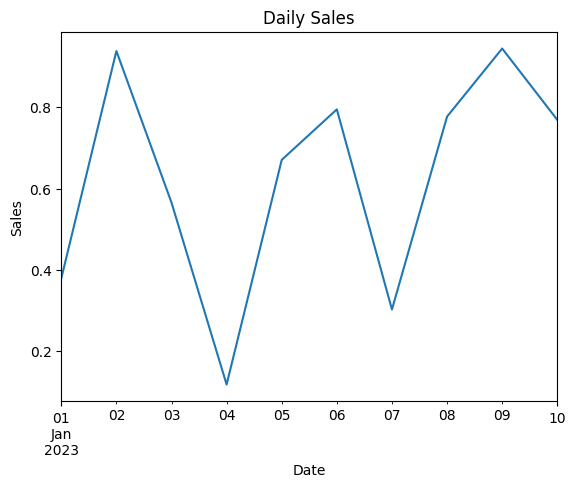

In [7]:
# Your Code Here
ax = df['sales'].plot()
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('Daily Sales')

### Exercise 1.4: Computing MAE and RMSE
**Instruction**: Given `truth` and `forecast` arrays, compute MAE and RMSE.

In [8]:
truth = np.array([100, 102, 98, 105])
forecast = np.array([101, 100, 100, 100])
# Your Code Here
mae = np.mean(np.abs(truth - forecast))
rmse = np.sqrt(np.mean((truth - forecast)**2))
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 2.5
RMSE: 2.9154759474226504


In [9]:
#| Check your work
try:
    assert 'mae' in locals(), "Variable 'mae' missing."
    print("Exercise 1.4 Passed!")
except Exception as e:
    print(f"Exercise 1.4 Failed: {e}")

Exercise 1.4 Passed!


## Part 2: Textbook Exercises

Complete the following exercises from *Forecasting: Principles and Practice, the Pythonic Way*.

### Chapter 1: Getting Started

#### Question 1.1
> For cases 3 and 4 in Section 1.5, list the possible predictor variables that might be useful, assuming that the relevant data are available.

**Answer:**
* For Case 3: Forecasting the resale value of individual vehicles after a 3-year lease period, possible predictors could be Vehicle specfications ( Make and Model, Electric or not, transmisstion, color), Condition and Usage (Mileage, Maintenance History, Accident History), Market ( Orginal MSRP, Fuel prices...)

* For Case 4: Forecasting weekly air passenger traffic, possible predictors could be Calendar & Scheduled Events(School or Public Holidays,  Major Events),
Airline Operational Decisions(Average tickets, seat capacity, Promotions/Advertising), Competitor Pricing & Capacity, Ecnonmic impact.

#### Question 1.2
> For case 3 in Section 1.5, describe the five steps of forecasting in the context of this project.

**Answer:**
Five steps as below:

1. Problem Definition:Defining the problem carefully requires an understanding of the way the forecasts will be used.

2. Gather Information: gather statsical data and the accumulated expertise of the people who collect the data and use the forecasts
3. Preliminary (Exploratory) Analysis: data visualization, analysis and cleaning.
4. Choosing and Fitting Models: model selection, paramter estimation
5. Using and Evaluating a Forecasting Model: evaluation, implemetation& Deployment, Feedback loop.


### Chapter 2: Time Series Graphics

#### Question 2.1
> Explore the following four time series: `Bricks` from `aus_production`, `Lynx` from `pelt`, `GOOG_Close` from `gafa_stock`, `Demand` from `vic_elec`.
> - Use `info()` to find out about the data in each series.
> - What is the time interval of each series?
> - Use `plot_series()` to produce a time plot of each series.
> - For the last plot, modify the axis labels and title.

#### Question 2.2
> Use `query()` to find what days corresponded to the peak closing price for each of the four stocks in `gafa_stock`.

#### Question 2.3
> Download `tute1.csv`, read it into Python, and convert it to time series. Construct time series plots of each of the three series (Sales, AdBudget, GDP).

#### Question 2.4
> Download `us_total.csv`. Create a dataframe with year as the index. Plot the annual natural gas consumption by state for the New England area.

#### Question 2.5
> Download `tourism.xlsx`. Find what combination of Region and Purpose had the maximum number of overnight trips on average. Create a new dataframe which combines the Purposes and Regions, and just has total trips by State.

#### Question 2.6
> Use `plot_series()` to visualize the `aus_arrivals` data. Use seasonal and subseries plots to compare arrivals from Japan, NZ, UK, and US.

#### Question 2.7
> Select a random series from `aus_retail`. Explore it using `plot_series()`, `seasonal_decompose()`, `lag_plot()`, and `plot_acf()`. Can you spot seasonality, cyclicity, or trend?

#### Question 2.8
> Use `plot_series()`, `seasonal_decompose()`, `lag_plot()`, and `plot_acf()` to explore: "Total Private" Employed from `us_employment`, `Bricks` from `aus_production`, `Hare` from `pelt`, "H02" Cost from `PBS`, and `Barrels` from `us_gasoline`.

#### Question 2.9
> Extract pig slaughters in Victoria between 1990 and 1995 from `aus_livestock`. Plot the series and ACF. How do they differ from white noise?

#### Question 2.10
> Compute the daily changes in Google closing stock prices (`dgoog`). Plot the differences and their ACF. Do they look like white noise?

Question 2.1
The interval in data is : 91 days 00:00:00
--------------------------------------
The interval in data is : 1 days 00:00:00
--------------------------------------
The interval in data is : 365 days 00:00:00
--------------------------------------
The interval in data is : 0 days 00:30:00
--------------------------------------


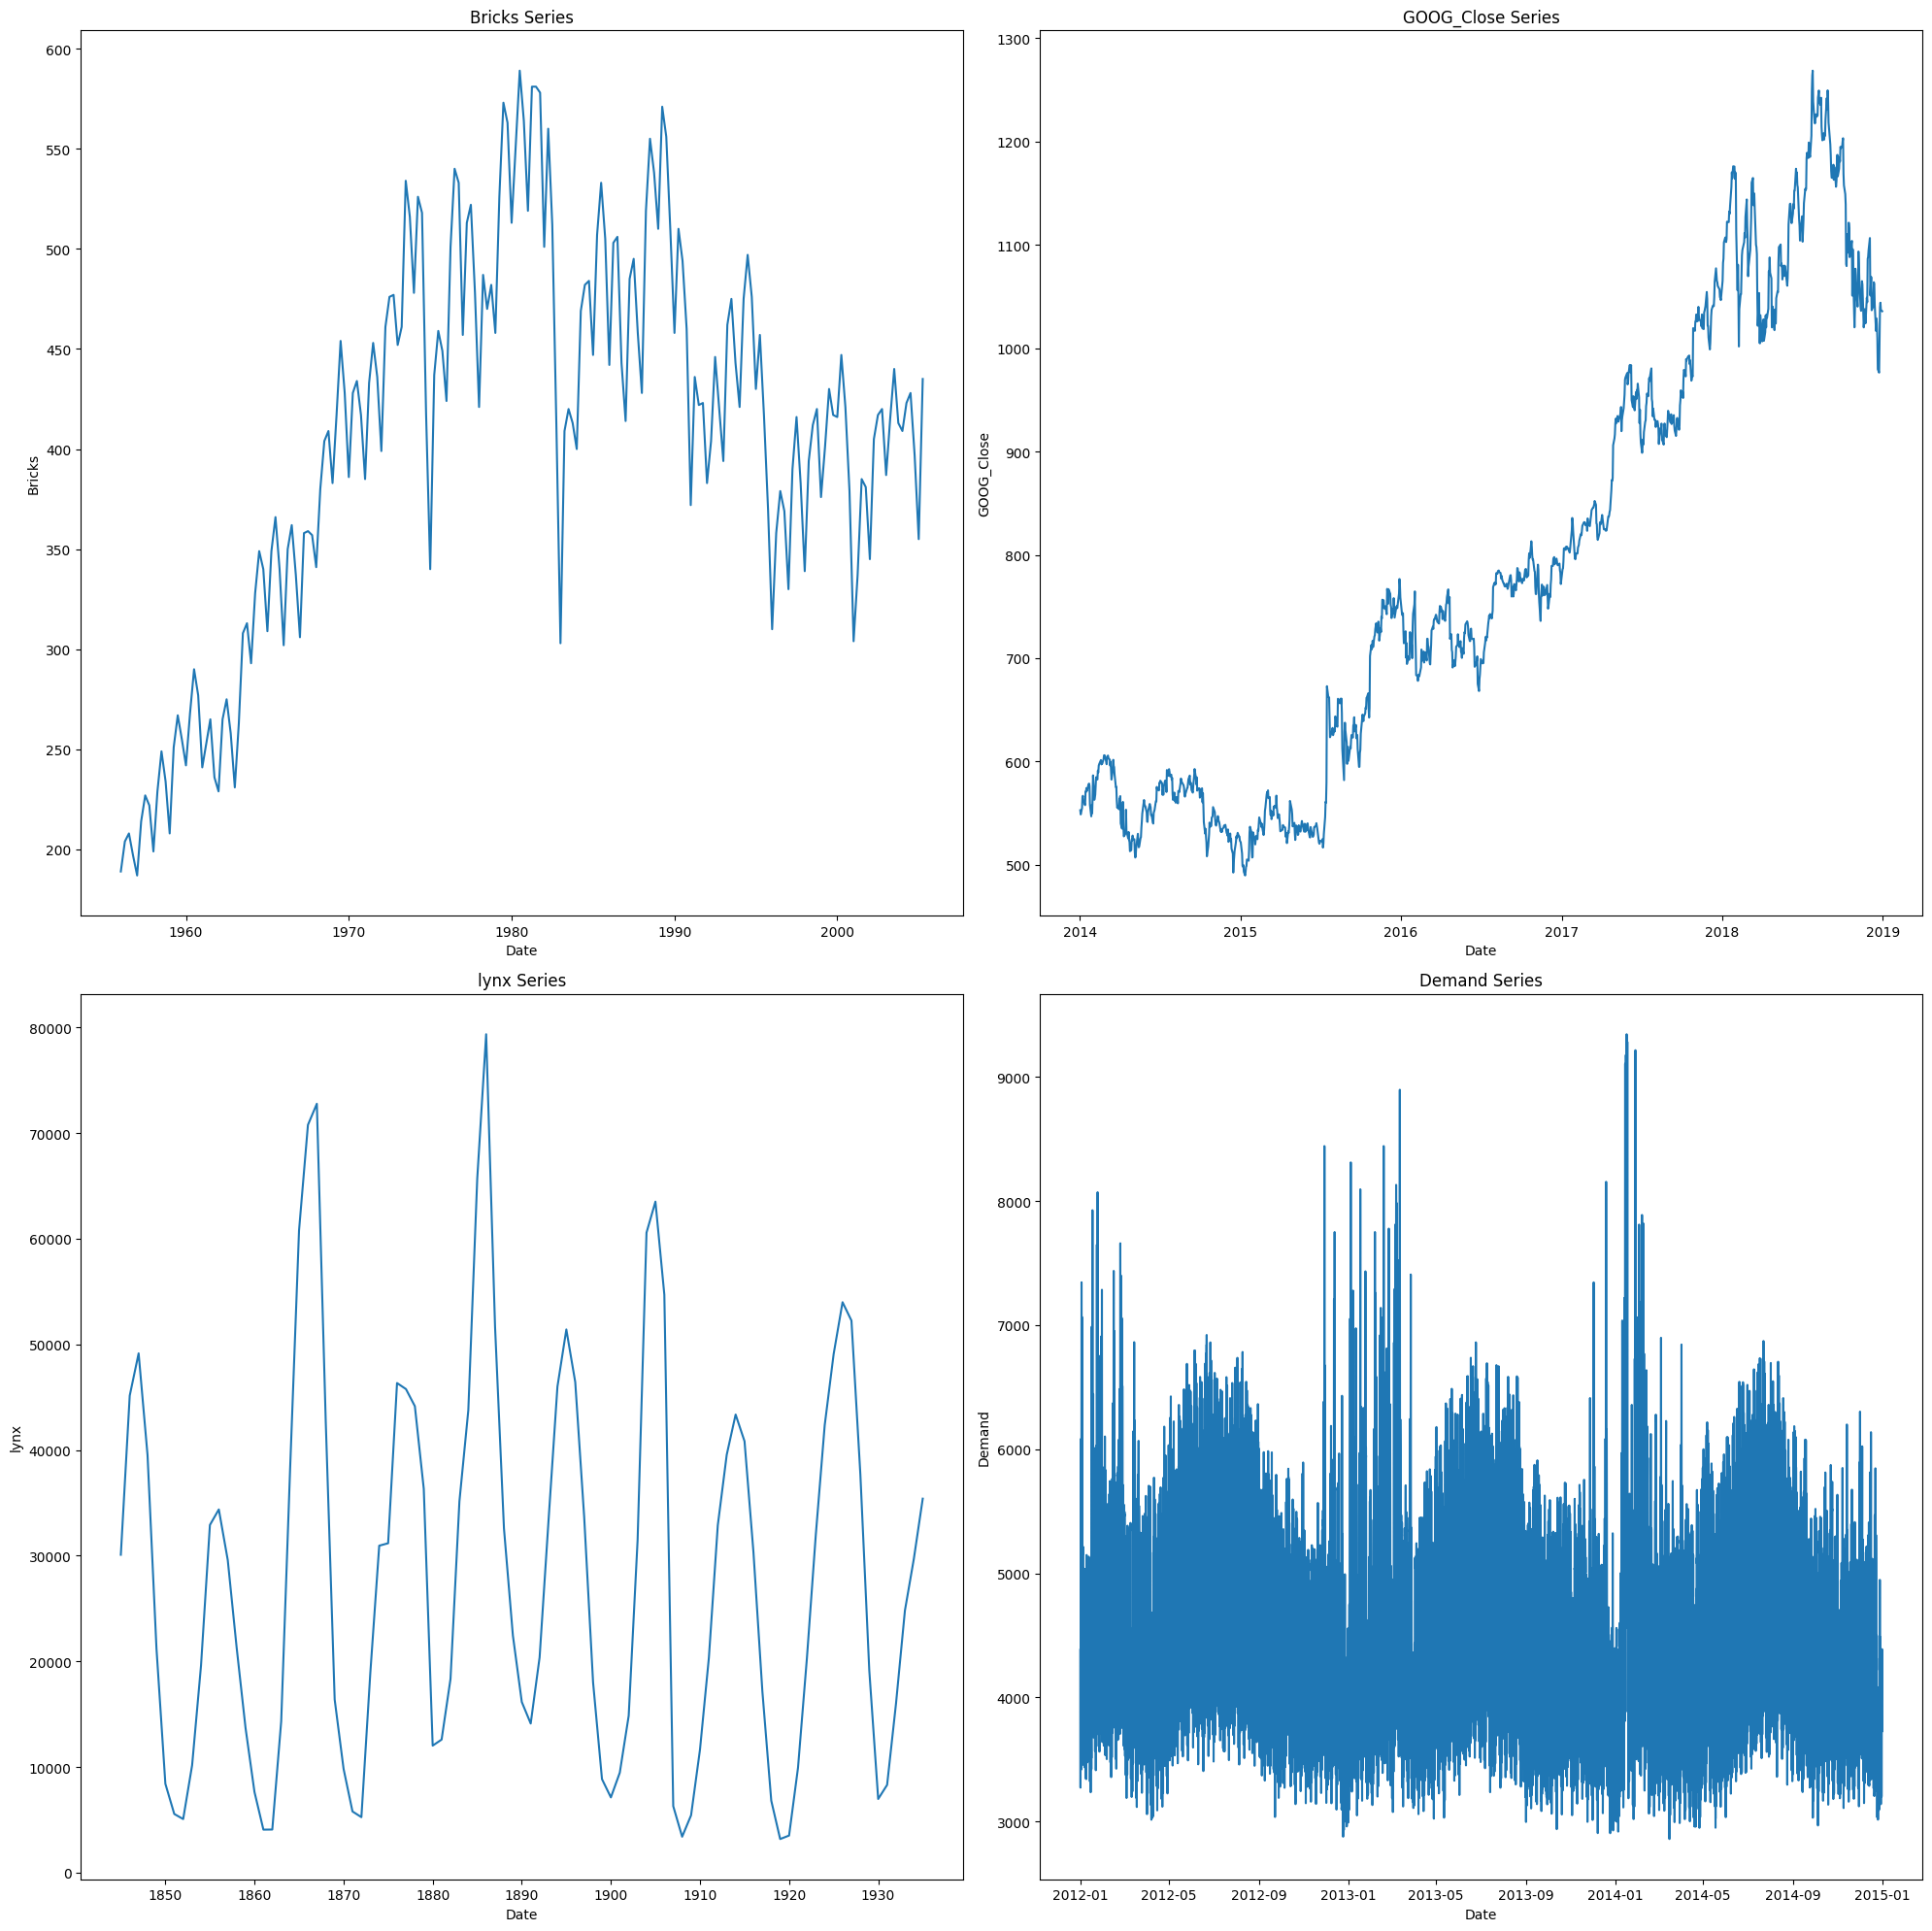

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

list_data = [
    ('Bricks', 'aus_production.csv'),
    ('GOOG_Close', 'gafa_stock.csv'),
    ('lynx', 'pelt.csv'),
    ('Demand', 'vic_elec.csv')
]
fig, axes = plt.subplots(2,2, figsize=(20,20))

print("Question 2.1")

for (col_name_to_plot, file), ax in zip(list_data, axes.flatten()):

    df_full = pd.read_csv(f'sample_data/{file}')

    # Convert 'ds' column to datetime and set as index
    df_full['ds'] = pd.to_datetime(df_full['ds'])
    df_full = df_full.set_index('ds')

    # Data selection based on file type and series name
    df_to_plot = None
    if col_name_to_plot in df_full.columns:
        # Series is a direct column (e.g., 'Bricks' in aus_production.csv)
        df_to_plot = df_full[[col_name_to_plot]]
    elif 'unique_id' in df_full.columns and 'y' in df_full.columns:
        # Series is identified by 'unique_id' with values in 'y' (e.g., gafa_stock.csv, pelt.csv, vic_elec.csv)
        df_filtered = df_full[df_full['unique_id'] == col_name_to_plot].copy()
        # Select the 'y' column and rename it to the desired column name for plotting
        df_to_plot = df_filtered[['y']].rename(columns={'y': col_name_to_plot})


    # Calculate and print the time interval
    print(f"The interval in data is : {abs(df_to_plot.index[0] - df_to_plot.index[1])}")
    print('--------------------------------------')

    # Plot the series on the current axis
    sns.lineplot(data=df_to_plot, x=df_to_plot.index, y=col_name_to_plot, ax=ax)
    ax.set_title(f'{col_name_to_plot} Series')
    ax.set_ylabel(col_name_to_plot)
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [35]:
print("Question 2.2")
# Use query() to find what days corresponded to the peak closing price
# for each of the four stocks in gafa_stock.

df_gafa_stock= pd.read_csv('sample_data/gafa_stock.csv')

filtered_df = df_gafa_stock[df_gafa_stock['unique_id'].str.contains('Close')]
filtered_df = filtered_df[~filtered_df['unique_id'].str.contains('Adj')]

idx = filtered_df.groupby('unique_id')['y'].idxmax().values
df_gafa_stock.loc[idx]

Question 2.2


,unique_id,ds,y
16293,AAPL_Close,2018-10-03,232.070007
17530,AMZN_Close,2018-09-04,2039.510010
18760,FB_Close,2018-07-25,217.500000
20019,GOOG_Close,2018-07-26,1268.329956


Question 2.3


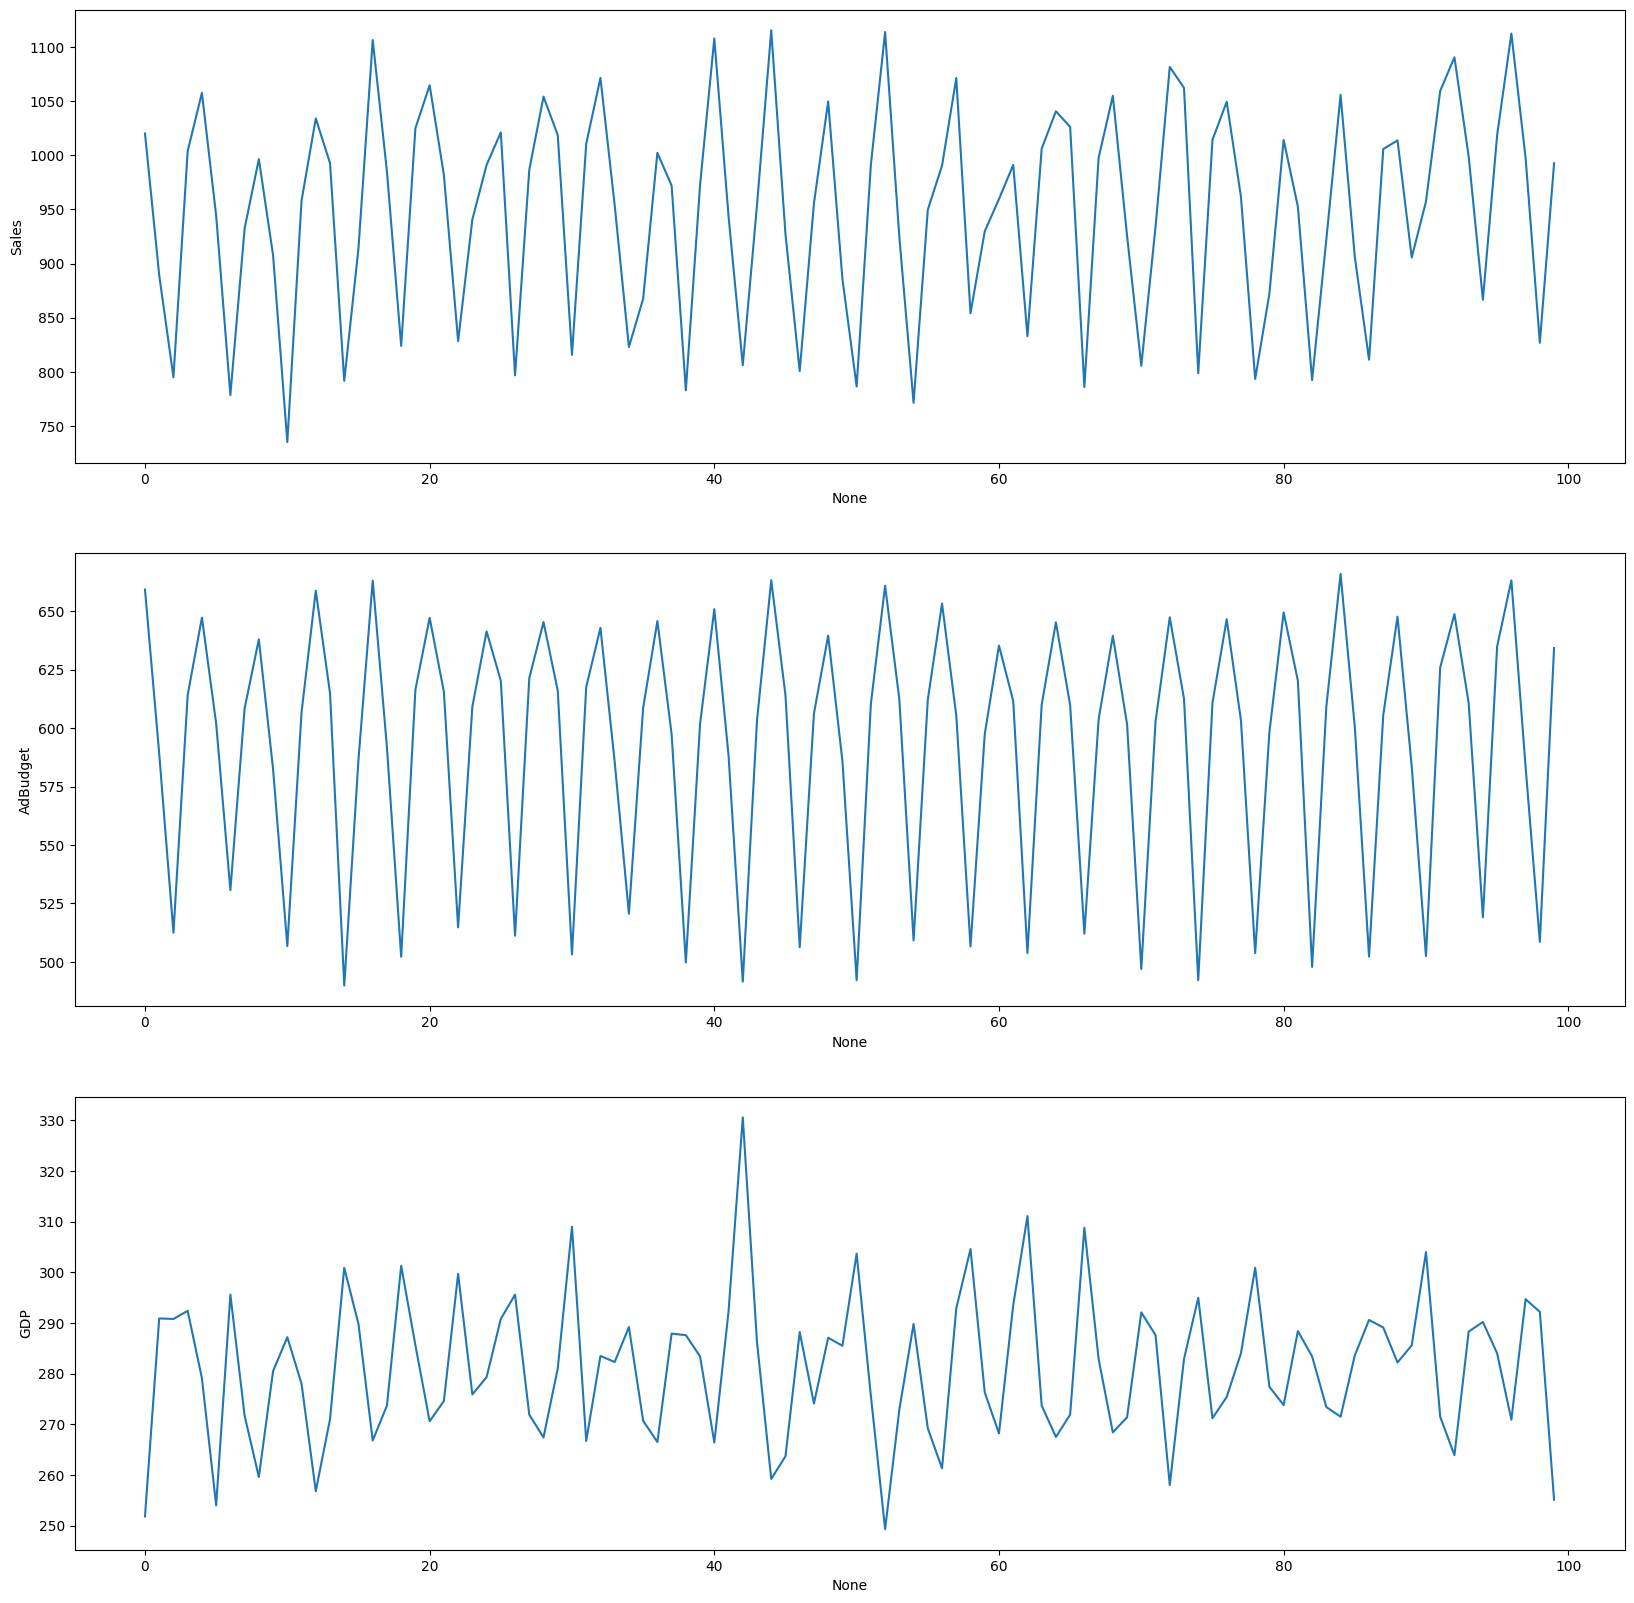

In [41]:
print("Question 2.3")
# Download tute1.csv, read it into Python, and convert it to time series.
# Construct time series plots of each of the three series (Sales, AdBudget, GDP).
df_tute1 = pd.read_csv('sample_data/tute1.csv')

df_tute1['Quarter'] = pd.to_datetime(df_tute1['Quarter'])

fig, axes = plt.subplots(3,1, figsize=(20,20))
cols = ['Sales', 'AdBudget', 'GDP']
for col, ax in zip(cols, axes.flatten()):
    sns.lineplot(data=df_tute1, x=df_tute1.index, y=col, ax=ax)



In [42]:
df_tute1.corr()

,Quarter,Sales,AdBudget,GDP
Quarter,1.000000,0.082964,-0.005185,0.061972
Sales,0.082964,1.000000,0.907765,-0.635961
AdBudget,-0.005185,0.907765,1.000000,-0.768860
GDP,0.061972,-0.635961,-0.768860,1.000000


Question 2.4


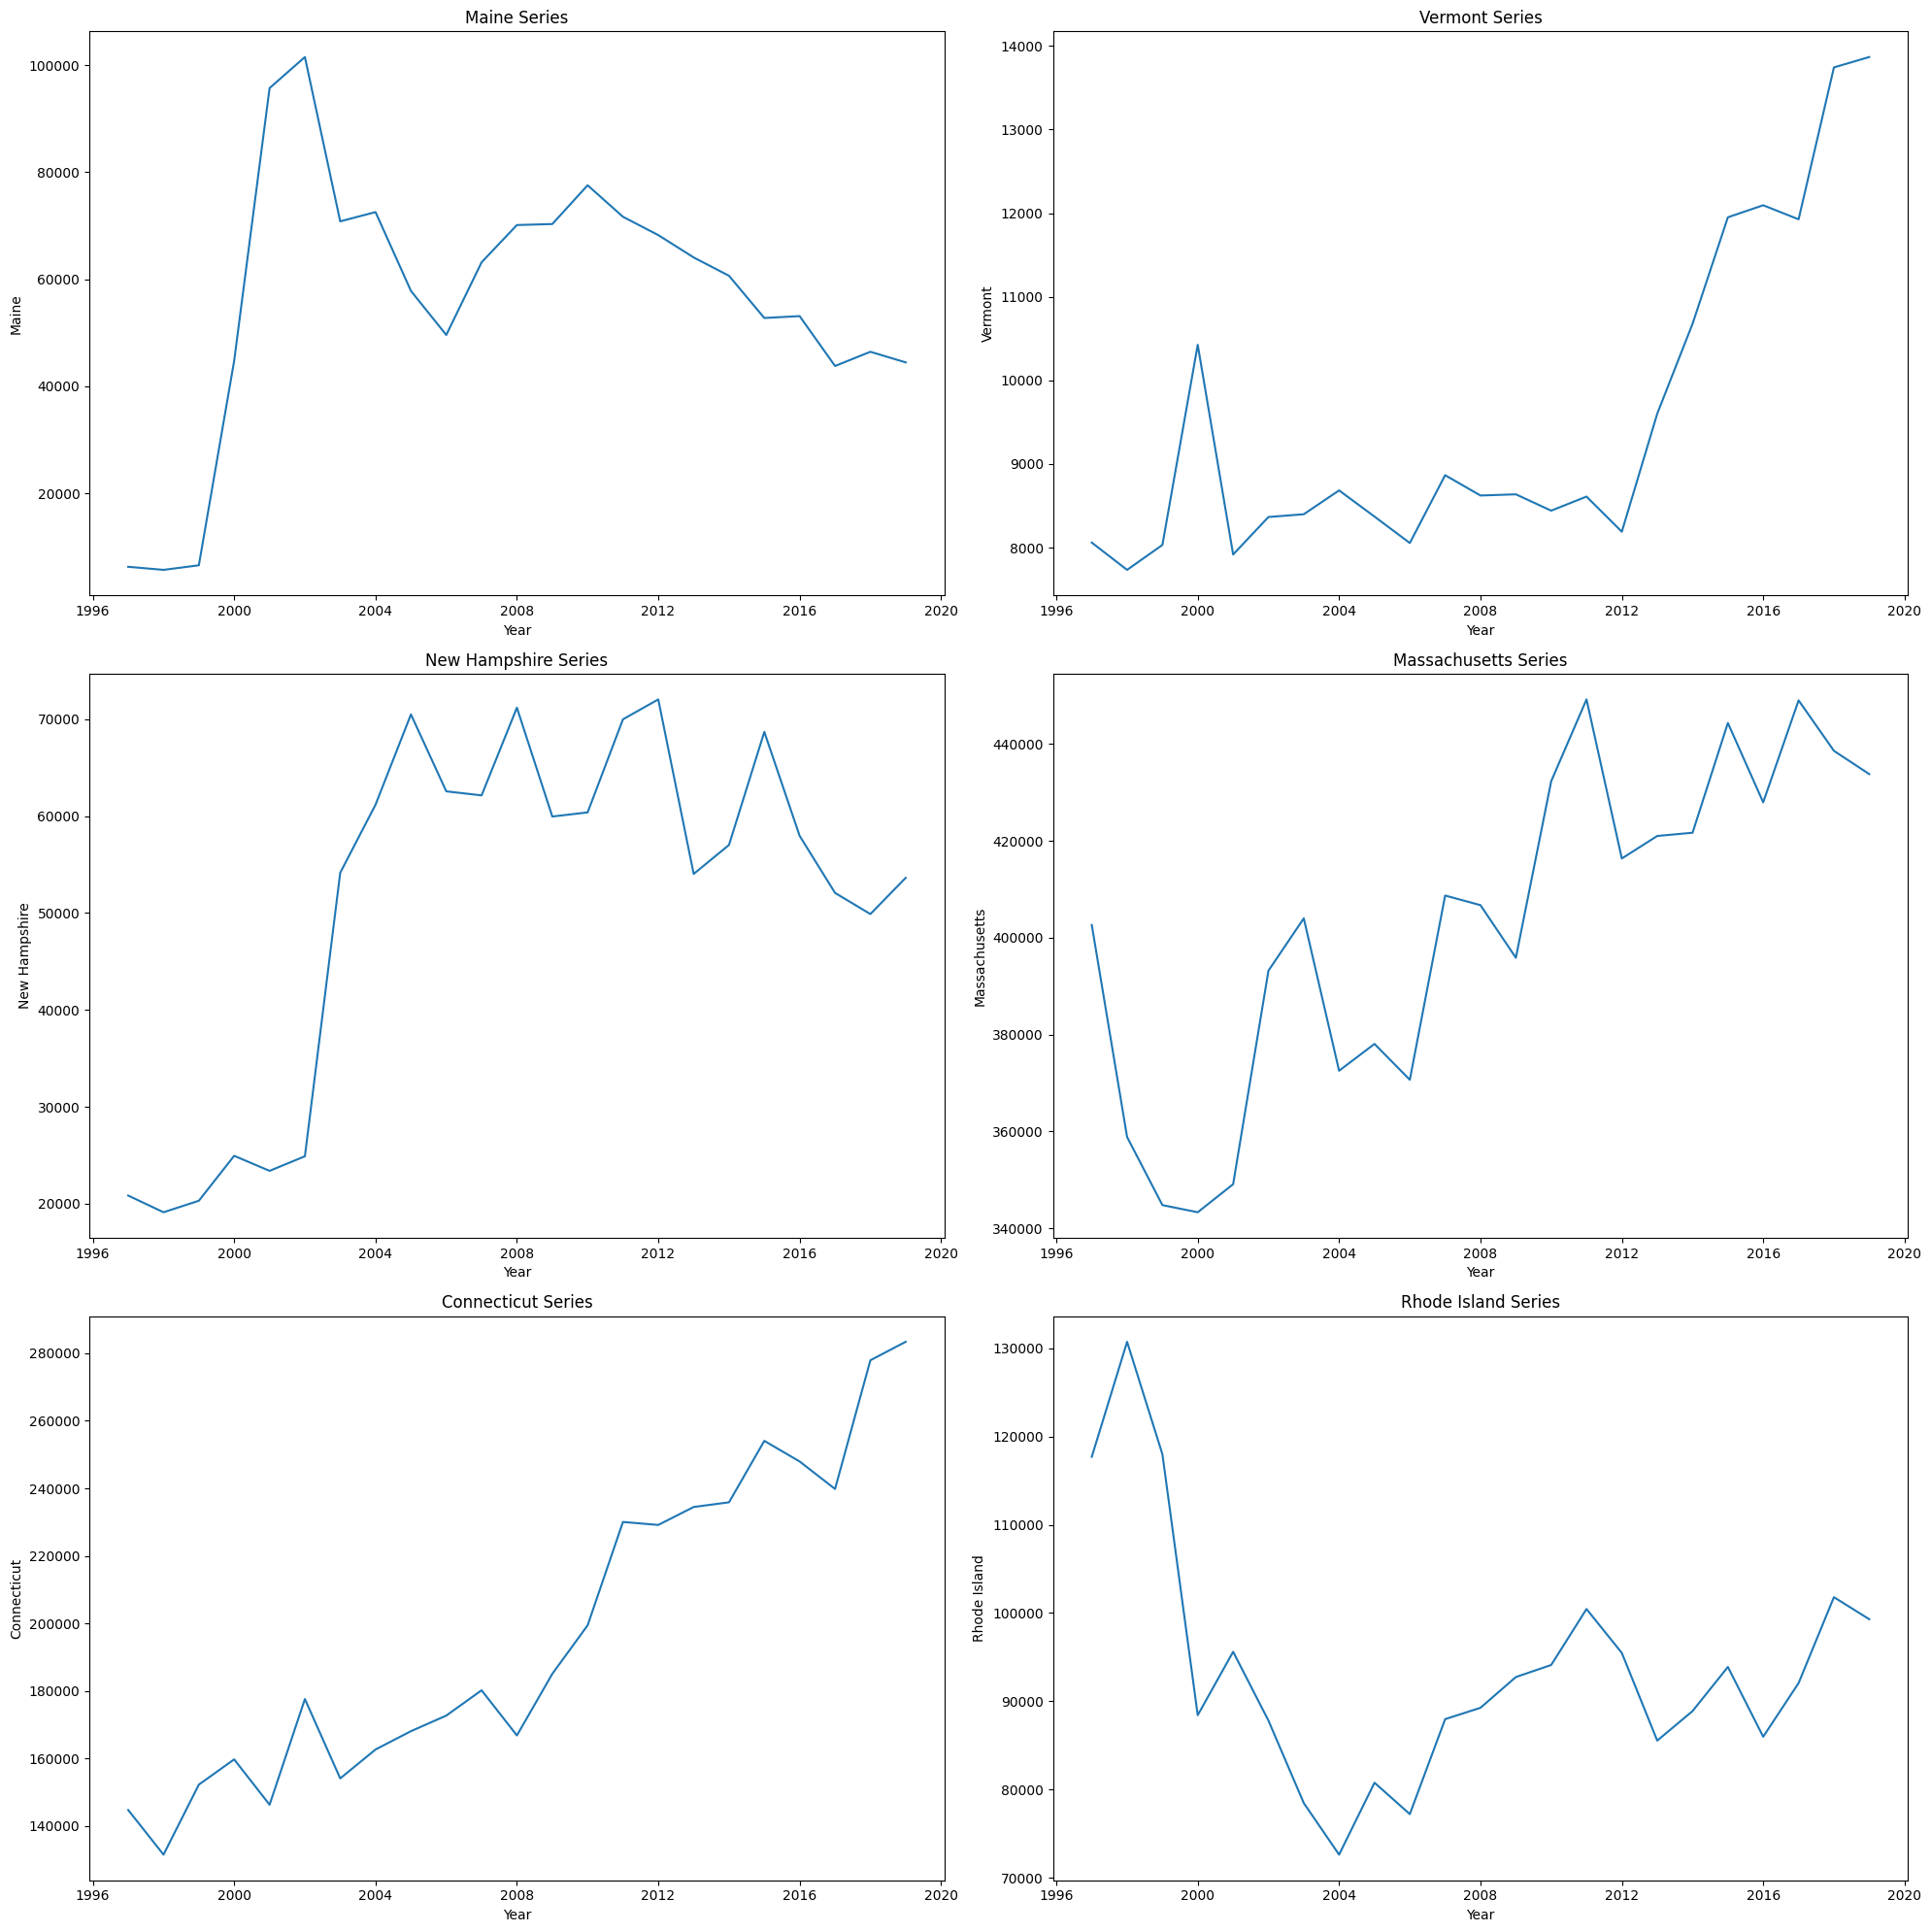

In [54]:
print("Question 2.4")
# Download us_total.csv. Create a dataframe with year as
# the index. Plot the annual natural gas consumption by state for the New England area.

df_us_total = pd.read_csv('sample_data/us_total.csv')
df_us_total['ds'] = pd.to_datetime(df_us_total['ds'], format='%Y')
df_us_total = df_us_total.set_index('ds')

fig,axes = plt.subplots(3,2, figsize=(20,20))
ne_states = ['Maine', 'Vermont', 'New Hampshire', 'Massachusetts', 'Connecticut', 'Rhode Island']

for ne_states, ax in zip(ne_states, axes.flatten()):
    df_ne = df_us_total[df_us_total['unique_id'] == ne_states]
    sns.lineplot(data=df_ne, x=df_ne.index, y='y', ax=ax)
    ax.set_title(f'{ne_states} Series')
    ax.set_ylabel(f'{ne_states}')
    ax.set_xlabel('Year')


plt.tight_layout()
plt.show()



In [71]:
print("Question 2.5")
# Download tourism.xlsx. Find what combination of Region and
# Purpose had the maximum number of overnight trips on average.
# Create a new dataframe which combines the Purposes and Regions,
# and just has total trips by State.

# The openpyxl library is encountering a TypeError related to styles.
# Trying to load the Excel file with 'data_only=True' to bypass parsing issues with styles and formulas.
import openpyxl # Explicitly import openpyxl, though pandas will handle it internally.

df_tourism = pd.read_excel('sample_data/tourism.xlsx', engine='openpyxl', engine_kwargs={'data_only': True})
df_tourism['ds'] = pd.to_datetime(df_tourism['ds'])
df_tourism = df_tourism.set_index('ds')

df_tourism_filtered = df_tourism[df_tourism['Purpose'] == 'Overnight']
df_tourism_filtered.head()

Question 2.5


TypeError: expected <class 'openpyxl.styles.fills.Fill'>

## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?